<a href="https://colab.research.google.com/github/AbdulrahmanB-25/EDA_Project/blob/main/EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#Load the required libraries for data handling and visualization.
!pip -q install geopandas shapely pyogrio

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
import geopandas as gpd

!rm -rf Saudi-Arabia-Regions-Cities-and-Districts
!git clone https://github.com/homaily/Saudi-Arabia-Regions-Cities-and-Districts.git

#Download the data (Must wait for the data to download before prosseding)

path = kagglehub.dataset_download("mohammedaldakhil/27k-riyadh-places-raw")
pd.set_option("display.max_rows", None)

Cloning into 'Saudi-Arabia-Regions-Cities-and-Districts'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 114 (delta 4), reused 4 (delta 4), pack-reused 105 (from 1)
Receiving objects: 100% (114/114), 44.42 MiB | 19.40 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Using Colab cache for faster access to the '27k-riyadh-places-raw' dataset.


In [7]:
#Display the first rows to verify that the dataset loaded correctly and to inspect the available columns.
#May need two time to run for the dataset to download
df=pd.read_csv("/kaggle/input/27k-riyadh-places-raw/final_dataset.csv")
print(f"\n The shape of it is :{df.shape}\n ")
df.head(50)


 The shape of it is :(26985, 17)
 


,Unnamed: 0,fsq_id,name,latitude,longitude,address,category,date_created,name_clean,suspicious_name,price,rating,total_photos,total_ratings,total_tips,tastes,tips
0,0,56e8116d498edadf1c556331,حنين الشام Haneen AlSham (حنين الشام),24.470214,46.273324,NaN,"['Middle Eastern Restaurant', 'Falafel Restaur...",2016-03-15,حنين الشام haneen alsham (حنين الشام),False,$$,7.3,3.0,8.0,NaN,[],[]
1,1,4fc243c9e4b08acaf4f01cb3,Mathaq Cafe (كافيه مذاق),24.471596,46.271654,"King Abdulaziz Rd, Al Muzāḩimīyah","['Coffee Shop', 'Breakfast Spot']",2012-05-27,mathaq cafe (كافيه مذاق),False,$,8.0,3.0,8.0,NaN,[],[]
2,2,4bb04ab2f964a520ea3f3ce3,Dorrat AlTaeef درة الطائف,24.469343,46.273202,"King Faisal St, Al Muzāḩimīyah",['Breakfast Spot'],2010-03-29,dorrat altaeef درة الطائف,False,$,NaN,2.0,NaN,NaN,[],[]
3,3,575fd79b498e91d207e922af,المحكمة العامة بالمزاحمية,24.469106,46.273003,NaN,['Courthouse'],2016-06-14,المحكمة العامة بالمزاحمية,False,NaN,NaN,2.0,NaN,NaN,[],[]
4,4,5bced3a0bd4009002c127c85,Fawal AlTaif,24.469393,46.273380,Al Muzahmiyah,['Restaurant'],2018-10-23,fawal altaif,False,NaN,NaN,NaN,NaN,NaN,[],[]
5,5,54bf20ce498ea4735eacf31c,Al Rawdhah Buffet (بوفية الروضة),24.470291,46.273352,NaN,['Breakfast Spot'],2015-01-21,al rawdhah buffet (بوفية الروضة),False,$,NaN,4.0,NaN,NaN,[],[]
6,6,5208edcb11d29d0bf1de7b84,عروس الشرق Aroos AlSharq,24.470718,46.273435,"Al Muzahmiyah (King Faisal Rd), Al Muzahmiyah","['Middle Eastern Restaurant', 'Sandwich Spot',...",2013-08-12,عروس الشرق aroos alsharq,False,$$,6.0,1.0,9.0,NaN,[],[]
7,7,5aed845a12f0a9002cb5185a,مدهال,24.466677,46.273550,Al Muzāḩimīyah 19671,['Café'],2018-05-05,مدهال,False,$,7.8,63.0,9.0,1.0,[],[]
8,8,4e23397cfa761d67108e9321,الدانات Al Danat,24.470428,46.273295,NaN,['Middle Eastern Restaurant'],2011-07-17,الدانات al danat,False,$$,NaN,1.0,NaN,NaN,[],[]
9,9,5591a018498e33441bf4a6e7,عيادات أسناني Asnani Dental,24.468863,46.273226,NaN,['Dentist'],2015-06-29,عيادات أسناني asnani dental,False,NaN,NaN,NaN,NaN,NaN,[],[]


In [8]:
#Check the dataset structure using info() to review column names, data types, and missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26985 entries, 0 to 26984
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       26985 non-null  int64  
 1   fsq_id           26985 non-null  object 
 2   name             26985 non-null  object 
 3   latitude         26985 non-null  float64
 4   longitude        26985 non-null  float64
 5   address          20685 non-null  object 
 6   category         26985 non-null  object 
 7   date_created     26984 non-null  object 
 8   name_clean       26985 non-null  object 
 9   suspicious_name  26985 non-null  bool   
 10  price            13787 non-null  object 
 11  rating           8385 non-null   float64
 12  total_photos     17886 non-null  float64
 13  total_ratings    8385 non-null   float64
 14  total_tips       10389 non-null  float64
 15  tastes           26985 non-null  object 
 16  tips             26985 non-null  object 
dtypes: bool(1), 

In [9]:
#Generate summary statistics for numerical columns to inspect ranges, central tendency, and possible anomalies.
df.describe()

,Unnamed: 0,latitude,longitude,rating,total_photos,total_ratings,total_tips
count,26985.000000,26985.000000,26985.000000,8385.000000,17886.000000,8385.000000,10389.000000
mean,13492.000000,24.725713,46.681830,7.812284,447.882702,137.857961,18.716238
std,7790.042843,0.110453,0.118190,0.857698,2917.226375,500.029637,72.050112
min,0.000000,24.459820,46.262027,4.700000,-16.000000,2.000000,1.000000
25%,6746.000000,24.639728,46.611969,7.300000,4.000000,14.000000,1.000000
50%,13492.000000,24.735462,46.689473,7.900000,15.000000,28.000000,3.000000
75%,20238.000000,24.805062,46.769207,8.400000,80.000000,83.000000,10.000000
max,26984.000000,24.973363,46.941929,9.600000,94226.000000,13016.000000,2210.000000


In [10]:
# Check for duplicate rows to confirm data uniqueness before cleaning.
df.duplicated().sum()

np.int64(0)

In [11]:
#Inspect missing values across all columns to identify which variables require cleaning or special handling.
df.isnull().sum()

,0
Unnamed: 0,0
fsq_id,0
name,0
latitude,0
longitude,0
address,6300
category,0
date_created,1
name_clean,0
suspicious_name,0


In [12]:
#Check tips and tastes separately because empty lists ([]) are stored as values and are not counted as nulls by default.
print("Fake Empty tips:", (df["tips"] == "[]").sum())
print("Fake Empty tastes:", (df["tastes"] == "[]").sum())


Fake Empty tips: 24976
Fake Empty tastes: 25126


In [13]:
#Most entries in tips and tastes are empty, and the remaining values are sparse, so these columns have limited analytical value in the current stage.

df["tips"] = df["tips"].replace("[]", np.nan)
df["tastes"] = df["tastes"].replace("[]", np.nan)

print("Real Missing tips:", df["tips"].isna().sum())
print("Real Missing tastes:", df["tastes"].isna().sum())

Real Missing tips: 24976
Real Missing tastes: 25126


In [14]:
#Remove the unnecessary CSV index column and apply the required missing-value handling for selected features.
df.drop(columns=["Unnamed: 0"], inplace=True)
#Filling total tips withe zero because if no tips then zero
df["total_tips"] = df["total_tips"].fillna(0)
#Filling total photos withe zero because if no photos then zero
df["total_photos"] = df["total_photos"].fillna(0)
#Because of the min of the total photots are -16 and that is not logicly possablile so we clean this too
df.loc[df["total_photos"] < 0, "total_photos"] = 0
df.isnull().sum()

,0
fsq_id,0
name,0
latitude,0
longitude,0
address,6300
category,0
date_created,1
name_clean,0
suspicious_name,0
price,13198


In [15]:
#Recheck the dataset after cleaning to confirm that the transformations were applied correctly.
#there are one date_created that is null but it maybe a food shop and we dont want to remove that
df.describe()

,latitude,longitude,rating,total_photos,total_ratings,total_tips
count,26985.000000,26985.000000,8385.000000,26985.000000,8385.000000,26985.000000
mean,24.725713,46.681830,7.812284,296.881638,137.857961,7.205596
std,0.110453,0.118190,0.857698,2384.405777,500.029637,45.622382
min,24.459820,46.262027,4.700000,0.000000,2.000000,0.000000
25%,24.639728,46.611969,7.300000,0.000000,14.000000,0.000000
50%,24.735462,46.689473,7.900000,3.000000,28.000000,0.000000
75%,24.805062,46.769207,8.400000,31.000000,83.000000,2.000000
max,24.973363,46.941929,9.600000,94226.000000,13016.000000,2210.000000


In [16]:
#Filter the dataset using food-related keywords in the category column to isolate restaurant and dining records only.
food_keywords = [
    "restaurant",
    "cafe",
    "coffee",
    "pizza",
    "burger",
    "sandwich",
    "shawarma",
    "kebab",
    "falafel",
    "bakery",
    "dessert",
    "ice cream",
    "donut",
    "juice",
    "smoothie",
    "bbq",
    "grill",
    "steak",
    "chicken",
    "seafood",
    "diner",
    "bistro",
    "buffet",
    "breakfast",
    "brunch",
    "waffle",
    "pancake",
    "crepe",
    "tea",
    "ramen",
    "sushi",
    "noodle",
    "taco",
    "mexican",
    "italian"
]

In [17]:
#Get the food related rows and puts it in the df_restaurants which we will use
df_restaurants = df[
    df["category"].str.contains('|'.join(food_keywords), case=False, na=False)
].reset_index(drop=True)
#Then we need to encode the price that we confirms its all food shop
df_restaurants["price_level"] = df["price"].str.count(r"\$")
df_restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9289 entries, 0 to 9288
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fsq_id           9289 non-null   object 
 1   name             9289 non-null   object 
 2   latitude         9289 non-null   float64
 3   longitude        9289 non-null   float64
 4   address          8350 non-null   object 
 5   category         9289 non-null   object 
 6   date_created     9288 non-null   object 
 7   name_clean       9289 non-null   object 
 8   suspicious_name  9289 non-null   bool   
 9   price            8536 non-null   object 
 10  rating           4745 non-null   float64
 11  total_photos     9289 non-null   float64
 12  total_ratings    4745 non-null   float64
 13  total_tips       9289 non-null   float64
 14  tastes           1449 non-null   object 
 15  tips             1541 non-null   object 
 16  price_level      4027 non-null   float64
dtypes: bool(1), fl

In [18]:
# Convert latitude and longitude to numeric format to ensure they are valid for geographic analysis.

df_restaurants["latitude"]  = pd.to_numeric(df_restaurants["latitude"],  errors="coerce")
df_restaurants["longitude"] = pd.to_numeric(df_restaurants["longitude"], errors="coerce")
df_restaurants = df_restaurants.dropna(subset=["latitude", "longitude"]).copy()

# Load Riyadh districts

districts = gpd.read_file(
    "Saudi-Arabia-Regions-Cities-and-Districts/geojson/districts.geojson"
)
riyadh_districts = districts[districts["city_id"] == 3].copy()
riyadh_districts = riyadh_districts.to_crs("EPSG:4326")

# Convert to GeoDataFrame

gdf = gpd.GeoDataFrame(
    df_restaurants,
    geometry=gpd.points_from_xy(df_restaurants["longitude"], df_restaurants["latitude"]),
    crs="EPSG:4326"
)

# Spatial join (exact match)

joined = gpd.sjoin(
    gdf,
    riyadh_districts[["name_en", "geometry"]],
    how="left",
    predicate="within"
)

if "index_right" in joined.columns:
    joined = joined.drop(columns=["index_right"])

joined["neighborhoods"] = joined["name_en"]

# Print how many failed the exact match

failed = joined["neighborhoods"].isna().sum()
total  = len(joined)
print(f"Exact match:  {total - failed}/{total} matched")
print(f"Failed/missed: {failed}/{total} — sending to fallback...")

# Fallback — nearest district for unmatched

missing_mask = joined["neighborhoods"].isna()

if missing_mask.sum() > 0:
    gdf_missing_proj      = gdf[missing_mask].copy().to_crs(epsg=32638)
    riyadh_districts_proj = riyadh_districts.to_crs(epsg=32638)

    nearest = gpd.sjoin_nearest(
        gdf_missing_proj,
        riyadh_districts_proj[["name_en", "geometry"]],
        how="left"
    )
    joined.loc[nearest.index, "neighborhoods"] = nearest["name_en"].values

print(f"After fallback: {joined['neighborhoods'].isna().sum()} still missing")

# Done — neighborhoods added to df_restaurants

df_restaurants["neighborhoods"] = joined["neighborhoods"].values


Exact match:  8696/9289 matched
Failed/missed: 593/9289 — sending to fallback...
After fallback: 0 still missing


In [19]:
#Inspect the filtered restaurant dataset to confirm that the final working subset is clean and consistent.
print(f"\n The shape of it is :{df_restaurants.shape}\n ")
df_restaurants.head(50)


 The shape of it is :(9289, 18)
 


,fsq_id,name,latitude,longitude,address,category,date_created,name_clean,suspicious_name,price,rating,total_photos,total_ratings,total_tips,tastes,tips,price_level,neighborhoods
0,56e8116d498edadf1c556331,حنين الشام Haneen AlSham (حنين الشام),24.470214,46.273324,NaN,"['Middle Eastern Restaurant', 'Falafel Restaur...",2016-03-15,حنين الشام haneen alsham (حنين الشام),False,$$,7.3,3.0,8.0,0.0,NaN,NaN,2.0,King Abdullah City For Energy
1,4fc243c9e4b08acaf4f01cb3,Mathaq Cafe (كافيه مذاق),24.471596,46.271654,"King Abdulaziz Rd, Al Muzāḩimīyah","['Coffee Shop', 'Breakfast Spot']",2012-05-27,mathaq cafe (كافيه مذاق),False,$,8.0,3.0,8.0,0.0,NaN,NaN,1.0,King Abdullah City For Energy
2,4bb04ab2f964a520ea3f3ce3,Dorrat AlTaeef درة الطائف,24.469343,46.273202,"King Faisal St, Al Muzāḩimīyah",['Breakfast Spot'],2010-03-29,dorrat altaeef درة الطائف,False,$,NaN,2.0,NaN,0.0,NaN,NaN,1.0,King Abdullah City For Energy
3,5bced3a0bd4009002c127c85,Fawal AlTaif,24.469393,46.273380,Al Muzahmiyah,['Restaurant'],2018-10-23,fawal altaif,False,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,King Abdullah City For Energy
4,54bf20ce498ea4735eacf31c,Al Rawdhah Buffet (بوفية الروضة),24.470291,46.273352,NaN,['Breakfast Spot'],2015-01-21,al rawdhah buffet (بوفية الروضة),False,$,NaN,4.0,NaN,0.0,NaN,NaN,NaN,King Abdullah City For Energy
5,5208edcb11d29d0bf1de7b84,عروس الشرق Aroos AlSharq,24.470718,46.273435,"Al Muzahmiyah (King Faisal Rd), Al Muzahmiyah","['Middle Eastern Restaurant', 'Sandwich Spot',...",2013-08-12,عروس الشرق aroos alsharq,False,$$,6.0,1.0,9.0,0.0,NaN,NaN,1.0,King Abdullah City For Energy
6,4e23397cfa761d67108e9321,الدانات Al Danat,24.470428,46.273295,NaN,['Middle Eastern Restaurant'],2011-07-17,الدانات al danat,False,$$,NaN,1.0,NaN,0.0,NaN,NaN,2.0,King Abdullah City For Energy
7,5d6993c92ce3400008b09fe7,Burger Night Grilled,24.468517,46.273422,"Ghirnatah (King Faisal Rd), Al Muzāḩimīyah 19671",['Burger Joint'],2019-08-30,burger night grilled,False,$,NaN,4.0,NaN,0.0,NaN,NaN,1.0,King Abdullah City For Energy
8,4ffeeffce4b0083221190a60,دانكن دونتس Dunkin' Donuts,24.472098,46.276990,NaN,['Donut Shop'],2012-07-12,دانكن دونتس dunkin' donuts,False,$,8.3,120.0,80.0,2.0,NaN,NaN,2.0,King Abdullah City For Energy
9,4b948f30f964a520727d34e3,Al Aseel (الأصيل),24.467888,46.273738,"King Faisal St, Al Muzāḩimīyah SA","['Middle Eastern Restaurant', 'Fast Food Resta...",2010-03-08,al aseel (الأصيل),False,$$,NaN,1.0,NaN,2.0,NaN,NaN,NaN,King Abdullah City For Energy


In [20]:
#For extra checkup lets look at the statsic summry and null values
df_restaurants.describe()

,latitude,longitude,rating,total_photos,total_ratings,total_tips,price_level
count,9289.000000,9289.000000,4745.000000,9289.000000,4745.000000,9289.000000,4027.000000
mean,24.721081,46.685475,7.823836,602.481968,160.756164,15.654753,1.060343
std,0.098004,0.097384,0.859114,3357.120004,469.913363,66.505797,0.718491
min,24.461685,46.269028,4.700000,0.000000,2.000000,0.000000,0.000000
25%,24.646662,46.622211,7.300000,1.000000,15.000000,0.000000,1.000000
50%,24.738860,46.687681,7.900000,12.000000,36.000000,1.000000,1.000000
75%,24.797721,46.755041,8.500000,111.000000,113.000000,7.000000,1.000000
max,24.967605,46.941929,9.600000,94226.000000,12297.000000,2156.000000,4.000000


In [21]:
#Review the remaining missing values and preserve the ones that should stay as NaN to avoid introducing bias.
#The one date_created that is missing is a resturent and it doesnt matter if we leave it or take it so i am going to leave it
df_restaurants.isnull().sum()

,0
fsq_id,0
name,0
latitude,0
longitude,0
address,939
category,0
date_created,1
name_clean,0
suspicious_name,0
price,753


In [22]:
#Download the clean_data for streamlit
"""Remove this to download the csv
from google.colab import files
df_restaurants.to_csv("clean_data.csv", index=False)
files.download("clean_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

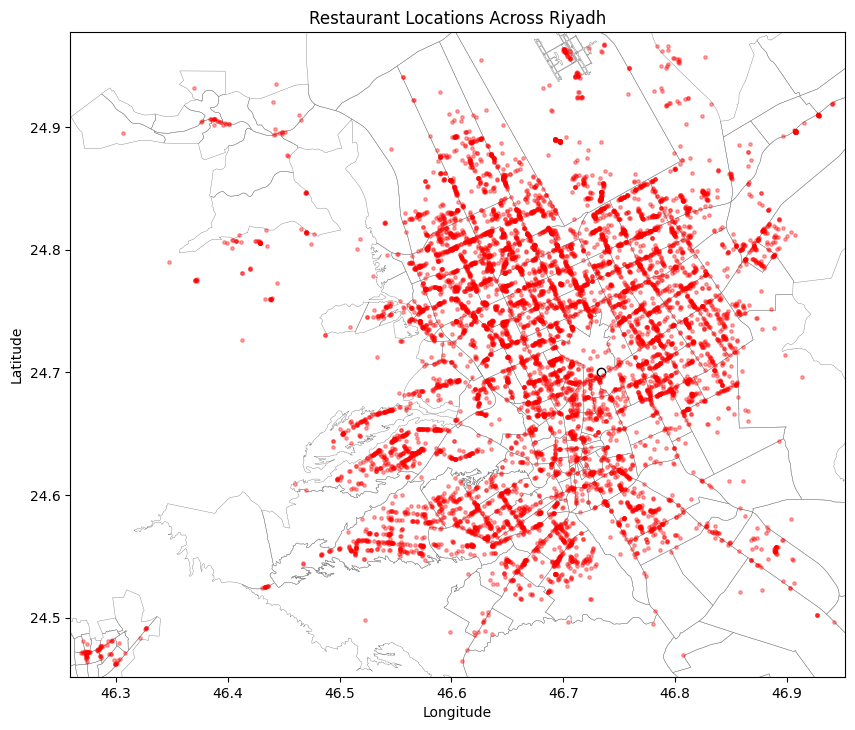


The map overlay shows that restaurants are not evenly distributed across Riyadh.
The highest concentration appears in the central and northern parts of the city,
while the outer areas contain fewer restaurant locations.
This pattern reflects the concentration of commercial activity and population density.


In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load Riyadh city boundary
cities = gpd.read_file("Saudi-Arabia-Regions-Cities-and-Districts/geojson/cities.geojson")

# Ensure same coordinate system
cities = cities.to_crs(epsg=4326)
districts = districts.to_crs(epsg=4326)

# Filter Riyadh city
riyadh = cities[cities["name_en"] == "Riyadh"]

# Plot
fig, ax = plt.subplots(figsize=(10,10))

# City boundary
riyadh.plot(ax=ax, color="#f5f5f5", edgecolor="black", linewidth=1)

# District borders
districts.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.3)

# Restaurant points
ax.scatter(
    df_restaurants["longitude"],
    df_restaurants["latitude"],
    color="red",
    s=6,
    alpha=0.35
)
ax.set_xlim(df_restaurants["longitude"].min()-0.01,
            df_restaurants["longitude"].max()+0.01)

ax.set_ylim(df_restaurants["latitude"].min()-0.01,
            df_restaurants["latitude"].max()+0.01)


ax.set_title("Restaurant Locations Across Riyadh")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

print("\nThe map overlay shows that restaurants are not evenly distributed across Riyadh.")
print("The highest concentration appears in the central and northern parts of the city,")
print("while the outer areas contain fewer restaurant locations.")
print("This pattern reflects the concentration of commercial activity and population density.")

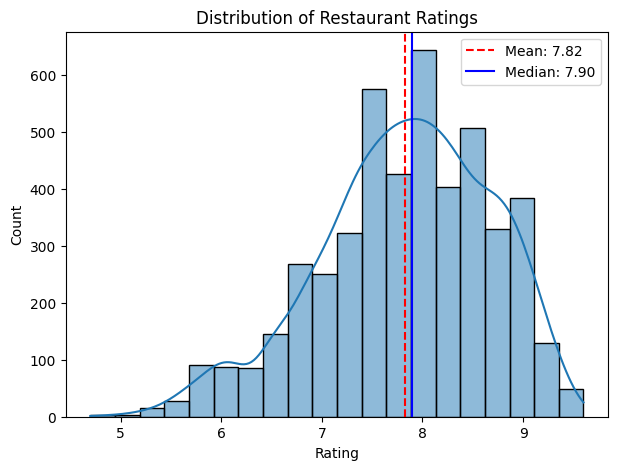


Most restaurants in Riyadh are rated between 7 and 9, with a mean of 7.82 and a median of 7.90, indicating a balanced distribution.
The highest concentration occurs just below 8, where most restaurants cluster.
Ratings below 6 are uncommon, suggesting that the city's dining scene generally maintains above-average quality.


In [24]:
plt.figure(figsize=(7,5))

sns.histplot(df_restaurants["rating"], bins=20, kde=True)

mean_rating = df_restaurants["rating"].mean()
median_rating = df_restaurants["rating"].median()

plt.axvline(mean_rating, color="red", linestyle="--", label=f"Mean: {mean_rating:.2f}")
plt.axvline(median_rating, color="blue", linestyle="-", label=f"Median: {median_rating:.2f}")

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.legend()

plt.show()
print("\nMost restaurants in Riyadh are rated between 7 and 9, with a mean of 7.82 and a median of 7.90, indicating a balanced distribution.\nThe highest concentration occurs just below 8, where most restaurants cluster.\nRatings below 6 are uncommon, suggesting that the city's dining scene generally maintains above-average quality.")

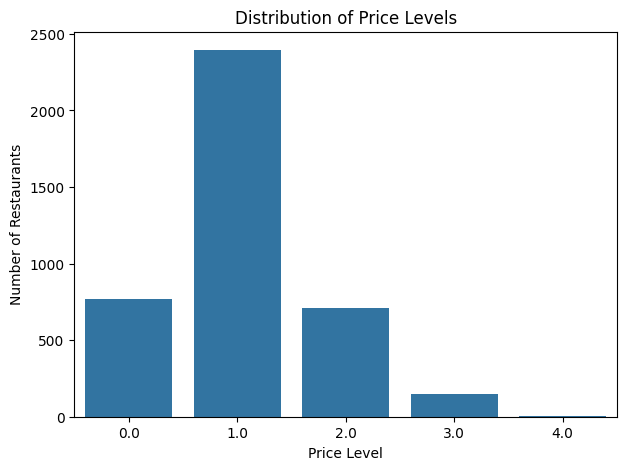

Price level 1 ($) dominates with about 2,400 restaurants — nearly three times more than any other price tier.
Mid-range level 2 ($$) follows with around 700 venues, while budget level 0 (unpriced) accounts for roughly 800.
Premium dining is rare: level 3 ($$$) has about 150 restaurants and level 4 ($$$$) is nearly absent. Overall,
Riyadh’s food scene is strongly skewed toward affordable dining, with high-end restaurants representing less than 4% of all venues.


In [25]:
plt.figure(figsize=(7,5))

sns.countplot(x="price_level", data=df_restaurants)

plt.title("Distribution of Price Levels")
plt.xlabel("Price Level")
plt.ylabel("Number of Restaurants")

plt.show()

print("Price level 1 ($) dominates with about 2,400 restaurants — nearly three times more than any other price tier.\nMid-range level 2 ($$) follows with around 700 venues, while budget level 0 (unpriced) accounts for roughly 800.\nPremium dining is rare: level 3 ($$$) has about 150 restaurants and level 4 ($$$$) is nearly absent. Overall,\nRiyadh’s food scene is strongly skewed toward affordable dining, with high-end restaurants representing less than 4% of all venues.")

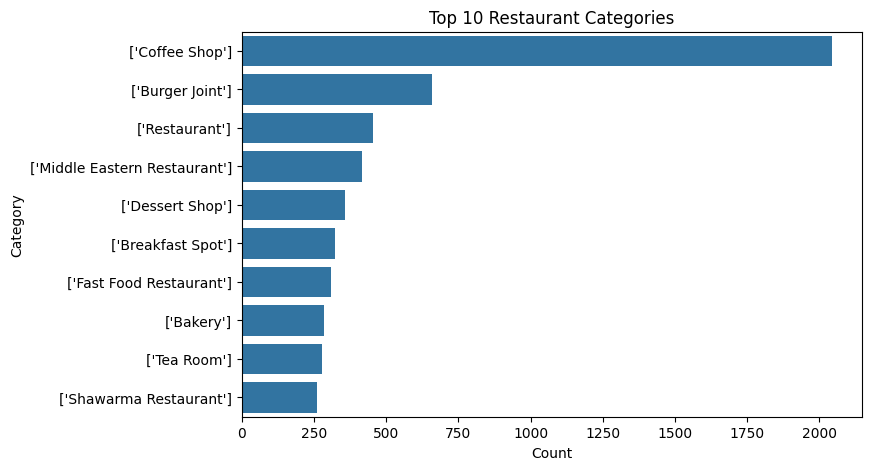

Coffee Shop is the most common category with about 2,050 venues — more than three times the second-ranked Burger Joint (~640).
Restaurant and Middle Eastern Restaurant follow with roughly 460 and 420 locations.
The remaining categories (Dessert Shop, Breakfast Spot, Fast Food, Bakery, Tea Room, and Shawarma) range between about 270 and 350 venues.
Overall, the dominance of Coffee Shops highlights the strong café culture in Riyadh’s food scene.


In [26]:
top_categories = df_restaurants["category"].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(y=top_categories.index, x=top_categories.values)

plt.title("Top 10 Restaurant Categories")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

print("Coffee Shop is the most common category with about 2,050 venues — more than three times the second-ranked Burger Joint (~640).\nRestaurant and Middle Eastern Restaurant follow with roughly 460 and 420 locations.\nThe remaining categories (Dessert Shop, Breakfast Spot, Fast Food, Bakery, Tea Room, and Shawarma) range between about 270 and 350 venues.\nOverall, the dominance of Coffee Shops highlights the strong café culture in Riyadh’s food scene.")

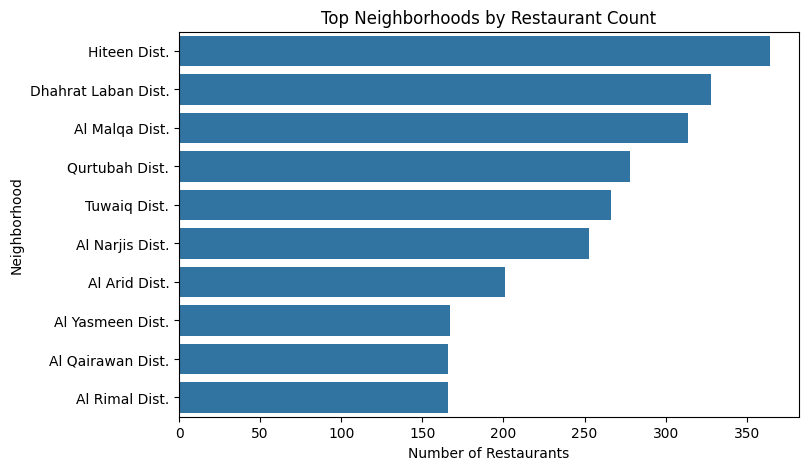

Hiteen District has the highest concentration with about 365 restaurants, followed by Dhahrat Laban (~328) and Al Malqa (~315). Qurtubah (~275) and Tuwaiq (~265) complete the top five.
The lowest counts appear in Al Yasmeen, Al Qairawan, and Al Rimal, each with around 160 venues.
The gap of over 200 restaurants between the highest and lowest areas shows that dining activity is heavily concentrated in the northern and northwestern districts of Riyadh.


In [27]:
top_neigh = df_restaurants["neighborhoods"].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(y=top_neigh.index, x=top_neigh.values)

plt.title("Top Neighborhoods by Restaurant Count")
plt.xlabel("Number of Restaurants")
plt.ylabel("Neighborhood")

plt.show()

print("Hiteen District has the highest concentration with about 365 restaurants, followed by Dhahrat Laban (~328) and Al Malqa (~315). Qurtubah (~275) and Tuwaiq (~265) complete the top five.\nThe lowest counts appear in Al Yasmeen, Al Qairawan, and Al Rimal, each with around 160 venues.\nThe gap of over 200 restaurants between the highest and lowest areas shows that dining activity is heavily concentrated in the northern and northwestern districts of Riyadh.")

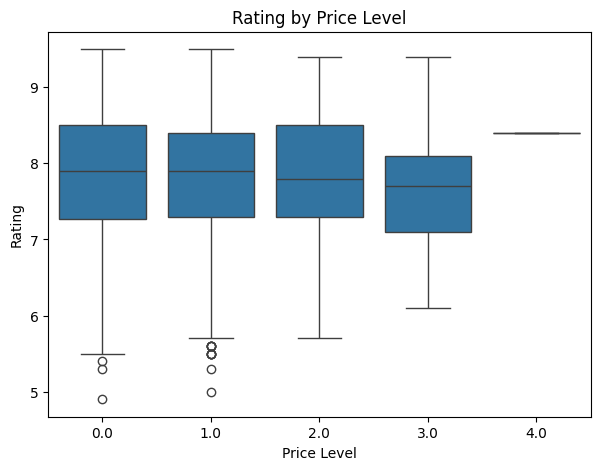

Price levels 0, 1, and 2 have nearly identical medians around 7.9–8.0 with similar spreads between roughly 7.3 and 8.5. Level 3 ($$$) shows a slightly lower median near 7.7, while level 4 ($$$$) contains only one observation, making it statistically insignificant.
Overall, the results indicate that higher prices do not necessarily correspond to higher ratings, as budget and mid-range restaurants achieve comparable customer satisfaction.


In [28]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x=df_restaurants["price_level"],
    y=df_restaurants["rating"]
)

plt.title("Rating by Price Level")
plt.xlabel("Price Level")
plt.ylabel("Rating")

plt.show()
print("Price levels 0, 1, and 2 have nearly identical medians around 7.9–8.0 with similar spreads between roughly 7.3 and 8.5. Level 3 ($$$) shows a slightly lower median near 7.7, while level 4 ($$$$) contains only one observation, making it statistically insignificant.\nOverall, the results indicate that higher prices do not necessarily correspond to higher ratings, as budget and mid-range restaurants achieve comparable customer satisfaction.")

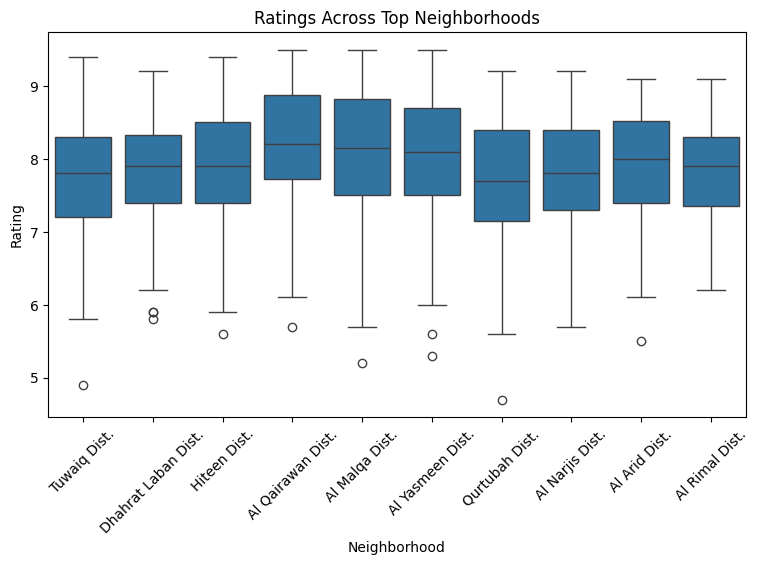

Al Qairawan and Al Malqa lead with the highest medians at ~8.2, while Tuwaiq and Qurtubah sit lowest at ~7.8. Most neighborhoods share a similar IQR of roughly 7.5–8.5,
but Al Yasmeen stands out with the widest spread and the lowest single outlier at ~4.7 — indicating highly inconsistent quality.
Hiteen, despite being the most restaurant-dense neighborhood, sits at a modest median of ~7.9.
Overall the differences between neighborhoods are small, suggesting rating quality is fairly uniform across Riyadh regardless of location.


In [29]:
top_neigh = df_restaurants["neighborhoods"].value_counts().head(10).index

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_restaurants[df_restaurants["neighborhoods"].isin(top_neigh)],
    x="neighborhoods",
    y="rating"
)

plt.xticks(rotation=45)
plt.title("Ratings Across Top Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Rating")

plt.show()

print("Al Qairawan and Al Malqa lead with the highest medians at ~8.2, while Tuwaiq and Qurtubah sit lowest at ~7.8. Most neighborhoods share a similar IQR of roughly 7.5–8.5,\nbut Al Yasmeen stands out with the widest spread and the lowest single outlier at ~4.7 — indicating highly inconsistent quality.\nHiteen, despite being the most restaurant-dense neighborhood, sits at a modest median of ~7.9.\nOverall the differences between neighborhoods are small, suggesting rating quality is fairly uniform across Riyadh regardless of location.")

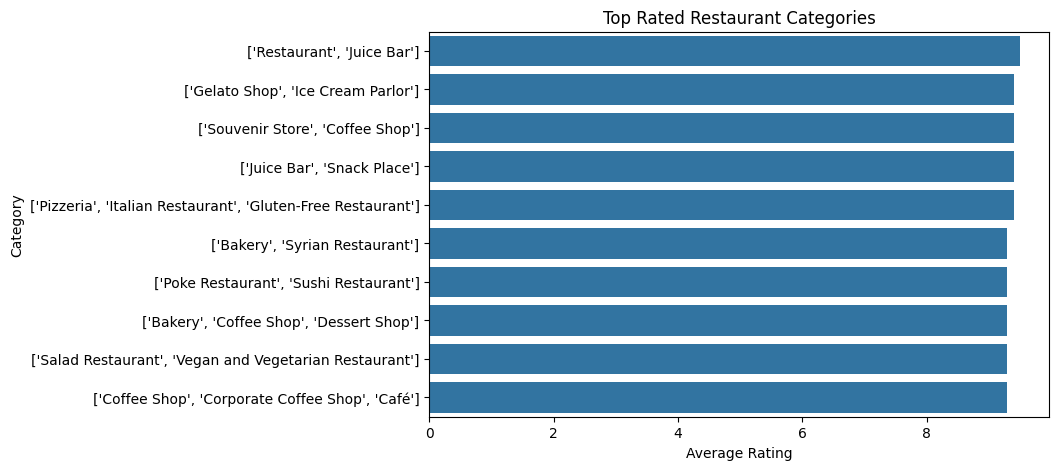

The top-rated category is Restaurant & Juice Bar at ~9.4, followed closely by Gelato & Ice Cream Parlor, Souvenir Store & Coffee Shop, and Juice Bar & Snack Place all at ~9.1–9.2. Notably, all 10 categories score between 9.0 and 9.4 — a very narrow range.
Every top-rated category is a multi-tag combination rather than a single type, suggesting that venues offering more than one concept tend to rate higher.
None of the most common categories from the countplot (Coffee Shop, Burger Joint) appear here, confirming that popularity and rating quality are inversely related in Riyadh's dining scene.


In [30]:
category_rating = (
    df_restaurants.groupby("category")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
sns.barplot(y=category_rating.index, x=category_rating.values)
plt.title("Top Rated Restaurant Categories")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.show()

print("The top-rated category is Restaurant & Juice Bar at ~9.4, followed closely by Gelato & Ice Cream Parlor, Souvenir Store & Coffee Shop, and Juice Bar & Snack Place all at ~9.1–9.2. Notably, all 10 categories score between 9.0 and 9.4 — a very narrow range.\nEvery top-rated category is a multi-tag combination rather than a single type, suggesting that venues offering more than one concept tend to rate higher.\nNone of the most common categories from the countplot (Coffee Shop, Burger Joint) appear here, confirming that popularity and rating quality are inversely related in Riyadh's dining scene.")

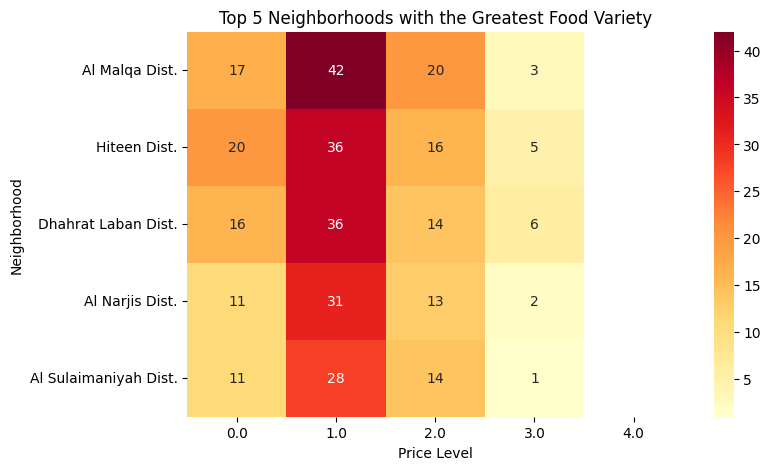

Al Malqa leads overall variety with 42 unique categories at price level 1 — the highest single cell in the entire heatmap. Hiteen and Dhahrat Laban both follow with 36 categories at level 1, while Al Narjis (31) and Al Sulaimaniyah (28) trail behind.
Across all 5 neighborhoods, price level 1 ($) is consistently the most diverse tier, followed by level 2 ($$) ranging from 13–20 categories. Premium dining (level 3) offers minimal variety, maxing out at just 6 categories in Dhahrat Laban.
Level 4 is completely absent across all top neighborhoods, confirming that food diversity in Riyadh is an affordable phenomenon.


In [31]:
# Create variety table
variety_table = (
    df_restaurants
    .groupby(["neighborhoods","price_level"])["category"]
    .nunique()
    .unstack()
)

# Find neighborhoods with highest total variety
top5_neigh = variety_table.sum(axis=1).sort_values(ascending=False).head(5).index

# Filter table
variety_top5 = variety_table.loc[top5_neigh]

# Plot heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    variety_top5,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title("Top 5 Neighborhoods with the Greatest Food Variety")
plt.xlabel("Price Level")
plt.ylabel("Neighborhood")

plt.show()

print("Al Malqa leads overall variety with 42 unique categories at price level 1 — the highest single cell in the entire heatmap. Hiteen and Dhahrat Laban both follow with 36 categories at level 1, while Al Narjis (31) and Al Sulaimaniyah (28) trail behind.\nAcross all 5 neighborhoods, price level 1 ($) is consistently the most diverse tier, followed by level 2 ($$) ranging from 13–20 categories. Premium dining (level 3) offers minimal variety, maxing out at just 6 categories in Dhahrat Laban.\nLevel 4 is completely absent across all top neighborhoods, confirming that food diversity in Riyadh is an affordable phenomenon.")

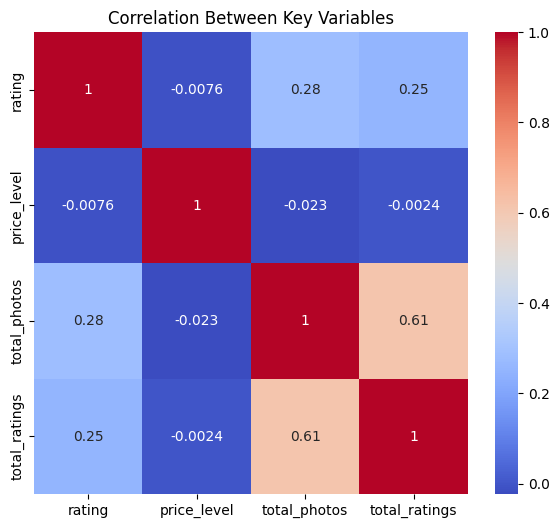

The strongest relationship appears between `total_photos` and `total_ratings` (0.61), indicating that restaurants with more photos also tend to accumulate more reviews, both reflecting overall popularity.
Rating shows weak positive correlations with `total_photos` (0.28) and `total_ratings` (0.25), suggesting that more visible restaurants tend to receive slightly higher ratings.
In contrast, `price_level` shows almost no correlation with rating, photos, or reviews, indicating that price has little relationship with restaurant quality or popularity in Riyadh.


In [32]:
plt.figure(figsize=(7,6))

sns.heatmap(
    df_restaurants[["rating","price_level","total_photos","total_ratings"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Key Variables")

plt.show()
print("The strongest relationship appears between `total_photos` and `total_ratings` (0.61), indicating that restaurants with more photos also tend to accumulate more reviews, both reflecting overall popularity.\nRating shows weak positive correlations with `total_photos` (0.28) and `total_ratings` (0.25), suggesting that more visible restaurants tend to receive slightly higher ratings.\nIn contrast, `price_level` shows almost no correlation with rating, photos, or reviews, indicating that price has little relationship with restaurant quality or popularity in Riyadh.")